In [1]:
import os
from typing import TypedDict, Annotated, List, Optional
from datetime import datetime

from langgraph.graph import StateGraph, END
from langgraph.types import interrupt
from openai import OpenAI

# from dotenv import load_dotenv

# load_dotenv()

# Initialize OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


In [2]:
from services.doctor_service import get_specialities_list, get_doctor_info, generate_time_slots
from services.booking_service import get_available_slots, confirm_booking

In [3]:
def call_llm(
    system_prompt: str,
    user_prompt: str,
    *,
    model: str = "gpt-4o-mini",
    temperature: float = 0,
    max_tokens: int = 50,
) -> str:
    """
    Centralized helper for all LLM calls.
    Returns the assistant's response
    """
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=temperature,
            max_tokens=max_tokens,
        )

        print(f"LLM response: {response.choices[0].message.content.strip()}")
        return response
    except Exception as e:
        print(f"LLM call error: {e}")
        return ""

In [4]:
system_prompt = """Answer this"""

user_prompt = "what is 2+2?"

response = call_llm(system_prompt, user_prompt)

response.choices[0].message.content.strip().lower()

LLM response: 2 + 2 equals 4.


'2 + 2 equals 4.'

In [54]:
class BookingState(TypedDict):
    """State for the booking conversation."""
    messages: Annotated[List[dict], lambda x, y: x + y]
    stage: str  # greeting, select_speciality, select_doctor, select_slot, confirm, completed
    selected_speciality: Optional[str]
    selected_doctor: Optional[dict]
    selected_slot: Optional[str]
    customer_name: Optional[str]
    customer_phone: Optional[str]
    booking_id: Optional[str]
    available_options: List[str]  # For clickable UI options


def create_initial_state():
    """Create initial state for the conversation."""
    return {
        "messages": [],
        "stage": "greeting",
        "selected_speciality": None,
        "selected_doctor": None,
        "selected_slot": None,
        "customer_name": None,
        "customer_phone": None,
        "booking_id": None,
        "available_options": []
    }


def is_message_on_topic(
    conversation_snippet: List[dict],
    current_stage: str,
    k: int = 4
) -> bool:
    """
    Guardrail: Uses LLM-only semantic classification to determine whether
    the recent conversation is related to booking a medical appointment.

    Args:
        messages: Full conversation history
        current_stage: Current booking stage
        k: Number of recent messages to include for context

    Returns:
        True if related to booking, False otherwise.
    """

    if not conversation_snippet:
        return True  # Nothing to evaluate

    # Map stage to human-readable context
    stage_context = {
        "greeting": "booking a medical appointment",
        "select_speciality": "choosing a medical speciality",
        "select_doctor": "choosing a doctor",
        "select_slot": "choosing an appointment time",
        "confirm": "confirming an appointment",
        "collect_details": "gettign the customer details for the appointment",
    }

    context = stage_context.get(current_stage, "booking a medical appointment")

    # Get last k messages for context
    # recent_messages = messages[-k:]

    # conversation_snippet = "\n".join(
    #     f"{m['role'].upper()}: {m['content']}"
    #     for m in recent_messages
    # )

    try:
        response = call_llm(
            system_prompt="""You are an intent classifier.

            Determine whether the conversation is related to booking a medical appointment.

            Respond with ONLY:
            - 'yes' → if the user is discussing symptoms, doctors, medical concerns, or appointment booking
            - 'no' → if the user is discussing unrelated topics like politics, sports, finance, coding, quotes, or general knowledge

            Do not explain. Only return 'yes' or 'no'.""",
                        user_prompt=f"""
            Current stage: {context}

            Recent conversation:
            {conversation_snippet}

            Is this conversation about booking a medical appointment?
            """,
            max_tokens=5
        )

        result = response.choices[0].message.content.strip().lower()

        return result == "yes"

    except Exception as e:
        print(f"⚠️ Topic check error: {e}. Allowing message through.")
        return True 


# Define valid routes for each stage (used to prevent invalid routing)
VALID_ROUTES_PER_STAGE = {
    "greeting": {"greeting", "select_speciality", "cancelled"},
    "select_speciality": {"select_speciality", "select_doctor"},
    "select_doctor": {"select_slot"},  # This node always goes to select_slot
    "select_slot": {"select_slot", "confirm"},
    "confirm": {"confirm", "collect_details", "cancelled"},
    "collect_details": {"collect_details", "completed"}
}


def llm_router(state: BookingState, k=4) -> str:
    """
    Routes the conversation based on user intent while enforcing guardrails.
    
    Logic:
    1. Check if message is on-topic; if not, add guardrail response and stay in current stage
    2. Route based on stage-specific logic
    3. Validate route is allowed for current stage; if not, default to current stage
    """
    current_stage = state["stage"]
    #last_user_msg = state["messages"][-1]["content"] if state["messages"] else ""
    messages = state["messages"]
    recent_messages = messages[-k:]
    conversation_snippet = "\n".join(
            f"{m['role'].upper()}: {m['content']}"
            for m in recent_messages)
    # ===== GUARDRAIL: Off-Topic Detection =====
    if state["messages"] and not is_message_on_topic(conversation_snippet,state["stage"],k=k):
        # Get last k messages for context
        
        recent_messages = messages[-k:]

        
        try:
            response = call_llm(
                system_prompt="""You are a friendly clinic booking assistant.
                When users ask off-topic questions, politely decline and redirect to booking.
                Keep response to 1-2 sentences. Be warm and helpful.""",
                user_prompt=f"""User asked something off-topic: "{conversation_snippet}"
                Generate a redirect response that politely declines and asks if they want to continue booking.""",
                max_tokens=50
            )
            off_topic_response = response.choices[0].message.content.strip()
            print(f"Generated off-topic response: {off_topic_response}")
        except:
            off_topic_response = "I'm sorry, I can only help with clinic bookings. Would you like to continue with your appointment?"
        
        state["messages"].append({
            "role": "assistant",
            "content": off_topic_response
        })
        return current_stage  # Stay in current stage

    # ===== ROUTING LOGIC: Route based on current stage and user message =====
    routing_prompts = {
        "greeting": f"""Analyze: "{conversation_snippet}"
        Does user want to book? Respond with ONLY: 'select_speciality' or 'cancelled'""",

        "select_speciality": f"""Analyze: "{conversation_snippet}"
        Is a speciality selected? (Current: {state['selected_speciality']})
        Respond with ONLY: 'select_doctor' or 'select_speciality'""",

        "select_slot": f"""Analyze: "{conversation_snippet}"
        Is a time slot selected? (Current: {state['selected_slot']})
        Respond with ONLY: 
        - 'confirm' if the slot is selected or 
        - 'select_slot' if the slot is not clear from the message to again ask user for slot selection""",

        "confirm": f"""Analyze: "{conversation_snippet}"
                    Does user confirm or cancel? 
                    Respond with ONLY: 
                    - 'collect_details' if confirmed
                    - 'cancelled' if cancelled
                    """
            }

    # If no routing prompt for this stage, return current stage (node handles transitions)
    if current_stage not in routing_prompts:
        return current_stage

    try:
        response = call_llm(
            system_prompt="You are a conversational AI routing expert. Always respond with ONLY the exact route name.",
            user_prompt=routing_prompts[current_stage],
            max_tokens=20
        )
        route = response.choices[0].message.content.strip().lower().replace("'", "").replace('"', "").strip()
        print(f"Routing decision: {route}")
    except Exception as e:
        print(f"⚠️ Routing error: {e}. Defaulting to {current_stage}")
        return current_stage

    # ===== VALIDATION: Ensure route is valid for current stage =====
    valid_routes = VALID_ROUTES_PER_STAGE.get(current_stage, {current_stage})
    
    if route not in valid_routes:
        print(f"⚠️ Invalid route '{route}' for stage '{current_stage}'. Valid: {valid_routes}. Defaulting to '{current_stage}'")
        return current_stage
    
    state["stage"] = route
    return route


def greeting_node(state: BookingState) -> BookingState:
    """Greets the user and pauses to see if they want to book."""
    user_input = interrupt("👋 Welcome to CarePlus! Would you like to book an appointment?")
    state["messages"].append({"role": "user", "content": user_input})
    return state


def select_speciality_node(state: BookingState) -> BookingState:
    """Handle speciality selection."""
    specialities = get_specialities_list()

    raw_user_input = interrupt({
        "role": "assistant",
        "content": "Please choose a speciality:",
        "available_options": specialities
    })
    
    prompt = f"""Extract the medical speciality from: "{raw_user_input}"
    Available: {', '.join(specialities)}
    Respond with ONLY the exact speciality name or "UNKNOWN"."""
    
    try:
        response = call_llm(
            system_prompt="You extract information from messages.",
            user_prompt=prompt,
            max_tokens=30
        )
        extracted = response.choices[0].message.content.strip()

        selected = None
        for spec in specialities:
            if spec.lower() in extracted.lower() or extracted.lower() in spec.lower():
                selected = spec
                break
        
        if selected:
            state["selected_speciality"] = selected
            state["stage"] = "select_doctor"
            state["messages"].append({"role": "user", "content": raw_user_input})
        else:
            state["messages"].append({
                "role": "assistant", 
                "content": f"I didn't recognize that. Pick from: {', '.join(specialities)}"
            })
    except Exception as e:
        print(f"Extraction error: {e}")

    return state


def select_doctor_node(state: BookingState) -> BookingState:
    """Identify the doctor and move to slot selection."""
    speciality = state["selected_speciality"]
    doctor = get_doctor_info(speciality)
    
    if not doctor:
        state["messages"].append({
            "role": "assistant",
            "content": "Sorry, no doctor available. Try another speciality."
        })
        state["stage"] = "select_speciality"
        return state
    
    state["selected_doctor"] = doctor
    state["stage"] = "select_slot"
    return state


def select_slot_node(state: BookingState) -> BookingState:
    """Handle time slot selection using interrupt and LLM extraction."""
    doctor = state["selected_doctor"]
    available_slots = generate_time_slots(doctor["office_timing"])

    message = f"We have {state['selected_speciality']}, {doctor['doctor_name']}. Pick a slot: {', '.join(available_slots)}"

    raw_user_input = interrupt({
        "role": "assistant",
        "content": message,
        "available_options": available_slots
    })

    prompt = f"""Extract the time slot from: "{raw_user_input}"
    Available: {', '.join(available_slots)}
    Respond with ONLY the exact time slot or "UNKNOWN"."""

    try:
        response = call_llm(
            system_prompt="You extract time slots from messages.",
            user_prompt=prompt,
            max_tokens=20
        )
        extracted = response.choices[0].message.content.strip()

        selected = next((s for s in available_slots if s.lower() in extracted.lower()), None)

        if selected:
            state["selected_slot"] = selected
            state["messages"].append({"role": "user", "content": raw_user_input})
        else:
            state["messages"].append({
                "role": "assistant",
                "content": "I didn't catch that. Which slot works?"
            })
    except Exception as e:
        print(f"Slot extraction error: {e}")

    return state


def confirm_node(state: BookingState) -> BookingState:
    """Handle confirmation stage."""
    doctor = state["selected_doctor"]
    slot = state["selected_slot"]
    
    message = f"""Review your appointment:

                **Doctor:** {doctor['doctor_name']}
                **Speciality:** {doctor['speciality']}
                **Time:** Today at {slot}

                Confirm or Cancel?"""

    user_choice = interrupt(message)

    state["messages"].append({
        "role": "user",
        "content": user_choice
    })

    # if user_choice.lower() == "confirm":
    #     state["stage"] = "completed"
    # else:
    #     state["stage"] = "cancelled"
        
    return state


def collect_details_node(state: BookingState) -> BookingState:
    """Collect patient details before final booking."""

    name = interrupt("Please enter your full name:")
    phone = interrupt("Please enter your phone number:")

    state["customer_name"] = name
    state["customer_phone"] = phone
    state["stage"] = "completed"

    return state


def completed_node(state: BookingState) -> BookingState:
    """Finalize booking and insert into database."""

    doctor = state["selected_doctor"]
    slot = state["selected_slot"]
    name = state["customer_name"]
    phone = state["customer_phone"]

    # 🔥 REAL DATABASE INSERT
    booking_id = confirm_booking(
        doctor_id=doctor["doctor_id"],
        customer_name=name,
        customer_phone=phone,
        time_slot=slot
    )

    state["booking_id"] = booking_id

    message = f"""✅ Appointment Confirmed!

                **Booking ID:** {booking_id}
                **Doctor:** {doctor['doctor_name']}
                **Time:** Today at {slot}

                Thank you for choosing CarePlus Clinic."""
    
    state["messages"].append({
        "role": "assistant",
        "content": message
    })

    state["available_options"] = []
    state["stage"] = "completed"

    return state


def cancelled_node(state: BookingState) -> BookingState:
    """Handle cancelled booking."""
    state["messages"].append({
        "role": "assistant",
        "content": "Thank you for connecting. Send 'hi' to restart your booking."
    })

    state["available_options"] = ["Book Again"]
    state["stage"] = "cancelled"

    return state

In [55]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

def build_booking_graph():
    workflow = StateGraph(BookingState)

    # 1. Add Nodes
    workflow.add_node("greeting", greeting_node)
    workflow.add_node("select_speciality", select_speciality_node)
    workflow.add_node("select_doctor", select_doctor_node)
    workflow.add_node("select_slot", select_slot_node)
    workflow.add_node("confirm", confirm_node)
    workflow.add_node("collect_details", collect_details_node)
    workflow.add_node("completed", completed_node)
    workflow.add_node("cancelled", cancelled_node)

    # 2. Set Entry Point
    workflow.set_entry_point("greeting")

    # 3. Add Conditional Edges WITH MAPPING
    # Format: add_conditional_edges(source_node, routing_function, mapping_dict)
    # Note: Each mapping includes the current stage to allow guardrail to keep user there for off-topic messages

    # The greeting node routes based on user intent
    workflow.add_conditional_edges(
        "greeting",
        llm_router,
        {
            "greeting": "greeting",
            "select_speciality": "select_speciality",
            "cancelled": "cancelled"
        }
    )

    workflow.add_conditional_edges(
        "select_speciality",
        llm_router,
        {
            "select_speciality": "select_speciality",
            "select_doctor": "select_doctor"
        }
    )

    # Direct pass from doctor to slot (no router needed here)
    workflow.add_edge("select_doctor", "select_slot")

    workflow.add_conditional_edges(
        "select_slot",
        llm_router,
        {
            "select_slot": "select_slot",
            "confirm": "confirm"
        }
    )

    workflow.add_conditional_edges(
        "confirm",
        llm_router,
        {
            "confirm": "confirm",
            "collect_details": "collect_details",
            "cancelled": "cancelled"
        }
    )
    workflow.add_edge("collect_details", "completed")
    # 4. Final Edges to END
    workflow.add_edge("completed", END)
    workflow.add_edge("cancelled", END)

    # 5. Compile with Checkpointer
    return workflow.compile(checkpointer=MemorySaver())

booking_graph = build_booking_graph()

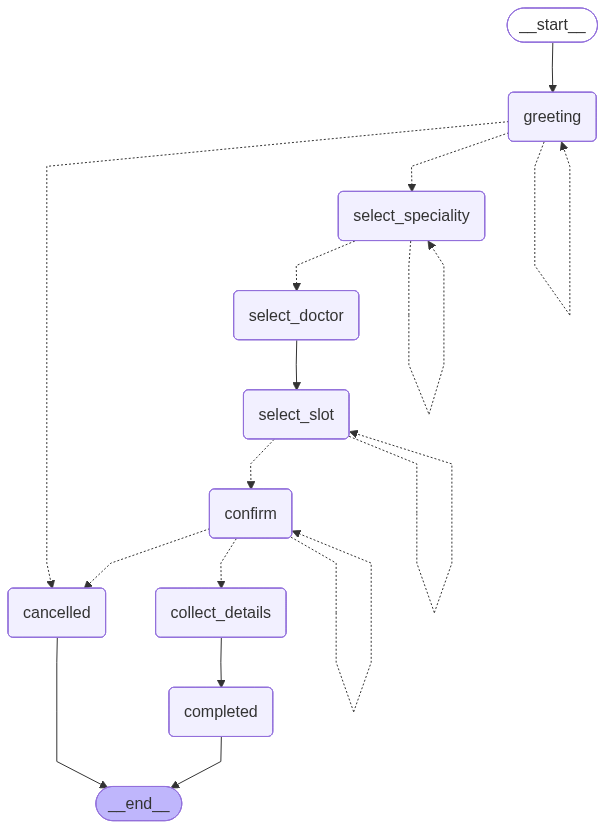

In [56]:
from IPython.display import Image, display

png_bytes = booking_graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

In [57]:
# Cell 1: Setup
from langgraph.checkpoint.memory import MemorySaver

# Initialize your graph and memory
memory = MemorySaver()
booking_graph = build_booking_graph() # This assumes your graph building function is defined

# Define config globally
config = {"configurable": {"thread_id": "test_new_02"}}

In [58]:
create_initial_state()

{'messages': [],
 'stage': 'greeting',
 'selected_speciality': None,
 'selected_doctor': None,
 'selected_slot': None,
 'customer_name': None,
 'customer_phone': None,
 'booking_id': None,
 'available_options': []}

In [59]:
from langgraph.types import Command

def run_booking_session(graph, thread_id="test_session_14", reset=False):
    config = {"configurable": {"thread_id": thread_id}}

    # 1. Start or Reset logic
    current_state = graph.get_state(config)
    if reset or not current_state.values:
        print(f"--- {'🔄 Resetting' if reset else '🆕 Initializing'} Session ---")
        # Using invoke() here kicks off the 'greeting' node immediately
        graph.invoke(create_initial_state(), config=config)

    print("---⚕⚕ Starting CarePlus Booking Session ---")
    
    last_displayed_message_idx = -1  # Track which messages have been displayed

    while True:
        state = graph.get_state(config)
        
        # Display any new assistant messages that haven't been shown yet
        # (This handles guardrail/off-topic responses)
        if state.values and state.values.get('messages'):
            messages = state.values['messages']
            for idx in range(last_displayed_message_idx + 1, len(messages)):
                msg = messages[idx]
                if msg.get("role") == "assistant":
                    print(f"\n[AI]: {msg['content']}")
            last_displayed_message_idx = len(messages) - 1

        # 2. Check for Interrupts
        if state.tasks and state.tasks[0].interrupts:
            interrupt_info = state.tasks[0].interrupts[0].value

            # --- FIX: Safely handle both String and Dict interrupts ---
            if isinstance(interrupt_info, dict):
                ai_message = interrupt_info.get('content', 'No message content')
                options = interrupt_info.get('available_options', [])
            else:
                ai_message = interrupt_info
                options = []

            print(f"\n[AI]: {ai_message}")
            if options:
                print(f"Options: {', '.join(options)}")
            # -------------------------------------------------------

            user_input = input("\n[YOU]: ")
            print(f"[YOU]: {user_input}")

            # Resume the graph with the user's input
            graph.invoke(Command(resume=user_input), config=config)

        # 3. Check if the graph has finished
        elif not state.next:
            # Before ending, check if there's a final assistant message to print
            if state.values and state.values.get('messages') and state.values['messages'][-1]["role"] == "assistant":
                if last_displayed_message_idx < len(state.values['messages']) - 1:
                    print(f"\n[AI]: {state.values['messages'][-1]['content']}")
            print("\n--- ⚑⚑ Session Ended ---")
            break

        # 4. If nodes are pending but no interrupt, let them run (the gas pedal)
        else:
            graph.invoke(None, config=config)

# IMPORTANT: Set reset=True only when you want to wipe the history.
# Set it to False to actually continue the conversation!
run_booking_session(booking_graph, reset=True)

--- 🔄 Resetting Session ---
---⚕⚕ Starting CarePlus Booking Session ---

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?
[YOU]: yes
LLM response: yes
LLM response: select_speciality
Routing decision: select_speciality

[AI]: Please choose a speciality:
Options: General Physician, Dermatologist, Orthopedic, Pediatrician, ENT Specialist
[YOU]: Derma
LLM response: Dermatologist
LLM response: yes

[AI]: We have Dermatologist, Dr. Neha Verma. Pick a slot: 11:00 AM, 12:00 PM, 1:00 PM, 2:00 PM, 3:00 PM
Options: 11:00 AM, 12:00 PM, 1:00 PM, 2:00 PM, 3:00 PM
[YOU]: 11
LLM response: 11:00 AM
LLM response: yes
LLM response: confirm
Routing decision: confirm

[AI]: Review your appointment:

                **Doctor:** Dr. Neha Verma
                **Speciality:** Dermatologist
                **Time:** Today at 11:00 AM

                Confirm or Cancel?
[YOU]: Confirm
LLM response: yes
LLM response: confirm
Routing decision: confirm

[AI]: Review your appointment:

         

KeyError: 'select_slot'

In [12]:
from langgraph.types import Command

def run_booking_session(graph, thread_id="test_session_14", reset=False):
    config = {"configurable": {"thread_id": thread_id}}

    # 1. Start or Reset logic
    current_state = graph.get_state(config)
    if reset or not current_state.values:
        print(f"--- {'🔄 Resetting' if reset else '🆕 Initializing'} Session ---")
        # Using invoke() here kicks off the 'greeting' node immediately
        graph.invoke(create_initial_state(), config=config)

    print("---⚕⚕ Starting CarePlus Booking Session ---")
    
    last_displayed_message_idx = -1  # Track which messages have been displayed

    while True:
        state = graph.get_state(config)
        
        # Display any new assistant messages that haven't been shown yet
        # (This handles guardrail/off-topic responses)
        if state.values and state.values.get('messages'):
            messages = state.values['messages']
            for idx in range(last_displayed_message_idx + 1, len(messages)):
                msg = messages[idx]
                if msg.get("role") == "assistant":
                    print(f"\n[AI]: {msg['content']}")
            last_displayed_message_idx = len(messages) - 1

        # 2. Check for Interrupts
        if state.tasks and state.tasks[0].interrupts:
            interrupt_info = state.tasks[0].interrupts[0].value

            # --- FIX: Safely handle both String and Dict interrupts ---
            if isinstance(interrupt_info, dict):
                ai_message = interrupt_info.get('content', 'No message content')
                options = interrupt_info.get('available_options', [])
            else:
                ai_message = interrupt_info
                options = []

            print(f"\n[AI]: {ai_message}")
            if options:
                print(f"Options: {', '.join(options)}")
            # -------------------------------------------------------

            user_input = input("\n[YOU]: ")
            print(f"[YOU]: {user_input}")

            # Resume the graph with the user's input
            graph.invoke(Command(resume=user_input), config=config)

        # 3. Check if the graph has finished
        elif not state.next:
            # Before ending, check if there's a final assistant message to print
            if state.values and state.values.get('messages') and state.values['messages'][-1]["role"] == "assistant":
                if last_displayed_message_idx < len(state.values['messages']) - 1:
                    print(f"\n[AI]: {state.values['messages'][-1]['content']}")
            print("\n--- ⚑⚑ Session Ended ---")
            break

        # 4. If nodes are pending but no interrupt, let them run (the gas pedal)
        else:
            graph.invoke(None, config=config)

# IMPORTANT: Set reset=True only when you want to wipe the history.
# Set it to False to actually continue the conversation!
run_booking_session(booking_graph, reset=True)

--- 🔄 Resetting Session ---
---⚕⚕ Starting CarePlus Booking Session ---

[AI]: ✅ Appointment Confirmed!

**Booking ID:** BKG-114933
**Doctor:** Dr. Anil Sharma
**Time:** Today at 10:00 AM

Thank you for choosing CarePlus Clinic.

[AI]: ✅ Appointment Confirmed!

**Booking ID:** BKG-114933
**Doctor:** Dr. Anil Sharma
**Time:** Today at 10:00 AM

Thank you for choosing CarePlus Clinic.

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?
[YOU]: Confirm
LLM response: no
LLM response: I’m here to help with your booking! Would you like to continue with scheduling an appointment?

[AI]: ✅ Appointment Confirmed!

**Booking ID:** BKG-114933
**Doctor:** Dr. Anil Sharma
**Time:** Today at 10:00 AM

Thank you for choosing CarePlus Clinic.

[AI]: ✅ Appointment Confirmed!

**Booking ID:** BKG-114933
**Doctor:** Dr. Anil Sharma
**Time:** Today at 10:00 AM

Thank you for choosing CarePlus Clinic.

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?
[YOU]: Cancle
LLM res